# Analyse de performance et détection d'anomalies — Parc éolien de Kelmarsh

Ce notebook exploite des données SCADA réelles d'une turbine du parc éolien de Kelmarsh
(Royaume-Uni, dataset public — [Zenodo](https://zenodo.org/record/8252025)) pour :

1. Construire la **courbe de puissance** de la turbine (relation vitesse du vent → puissance
   produite), la référence à partir de laquelle une performance "normale" est définie.
2. Détecter des **anomalies multivariées** via un Isolation Forest, en combinant plusieurs
   variables SCADA (puissance, vitesse rotor, températures, angle de pale).
3. Visualiser les résultats de façon interactive (Plotly), pour permettre l'exploration des
   anomalies détectées dans le temps et par rapport à la courbe de puissance.

Le déroulé suit une logique de pipeline classique en data science appliquée à l'industrie :
chargement et nettoyage des données brutes, construction d'une référence métier (la courbe de
puissance), puis modélisation.


## 1. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import plotly.graph_objects as go
import plotly.io as pio
import webbrowser

# Le renderer "iframe" est utilisé plutôt que le rendu inline par défaut : plus fiable
# avec certaines configurations de VS Code / Jupyter, où l'affichage inline de Plotly
# peut échouer silencieusement.
pio.renderers.default = "iframe"

In [2]:
# Dossier principal contenant les données brutes, organisées par année
DATASET_PATH = Path("dataset")

# Correspondance année -> dossier, tel que fourni par le dataset Kelmarsh
YEAR_FOLDERS = {
    2016: "Kelmarsh_SCADA_2016_3082",
    2017: "Kelmarsh_SCADA_2017_3083",
    2018: "Kelmarsh_SCADA_2018_3084",
    2019: "Kelmarsh_SCADA_2019_3085",
    2020: "Kelmarsh_SCADA_2020_3086",
}

# Identifiant de la turbine analysée. Le dataset en contient plusieurs ;
# l'analyse est volontairement restreinte à une seule turbine pour rester
# lisible et interprétable dans le temps imparti.
TURBINE_ID = 1

## 2. Chargement des données

Chaque année est fournie sous forme de fichiers CSV séparés (données SCADA et données de
statut). Le chargement boucle sur les années disponibles, ajoute l'année et l'identifiant de
turbine comme colonnes de contexte, puis conserve chaque DataFrame annuel en mémoire avant
fusion.

In [3]:
data_dfs = []
status_dfs = []

for year, folder_name in YEAR_FOLDERS.items():
    folder_path = DATASET_PATH / folder_name

    data_files = list(folder_path.glob(f"Turbine_Data_Kelmarsh_{TURBINE_ID}_*.csv"))
    status_files = list(folder_path.glob(f"Status_Kelmarsh_{TURBINE_ID}_*.csv"))

    print(f"{year} — {len(data_files)} fichier(s) data, {len(status_files)} fichier(s) status")

    for file in data_files:
        df = pd.read_csv(file)
        df["Year"] = year
        df["Turbine"] = TURBINE_ID
        data_dfs.append(df)

    for file in status_files:
        df = pd.read_csv(file)
        df["Year"] = year
        df["Turbine"] = TURBINE_ID
        status_dfs.append(df)

2016 — 1 fichier(s) data, 1 fichier(s) status
2017 — 1 fichier(s) data, 1 fichier(s) status
2018 — 1 fichier(s) data, 1 fichier(s) status
2019 — 1 fichier(s) data, 1 fichier(s) status
2020 — 1 fichier(s) data, 1 fichier(s) status


### Fusion des années en un unique DataFrame par type de données

In [4]:
df_data = pd.concat(data_dfs, ignore_index=True)
df_status = pd.concat(status_dfs, ignore_index=True)

print(f"Données SCADA : {len(df_data):,} lignes, {len(df_data.columns)} colonnes")
print(f"Données de statut : {len(df_status):,} lignes, {len(df_status.columns)} colonnes")

Données SCADA : 262,800 lignes, 301 colonnes
Données de statut : 36,719 lignes, 11 colonnes


In [5]:
df_data.head()

,Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)","Wind speed, Minimum (m/s)","Wind speed, Maximum (m/s)",Long Term Wind (m/s),Wind speed Sensor 1 (m/s),"Wind speed Sensor 1, Standard deviation (m/s)","Wind speed Sensor 1, Minimum (m/s)","Wind speed Sensor 1, Maximum (m/s)",...,"Tower Acceleration X, Max (mm/ss)","Tower Acceleration Y, Min (mm/ss)","Tower Acceleration Y, Max (mm/ss)","Drive train acceleration, Max (mm/ss)","Drive train acceleration, Min (mm/ss)","Drive train acceleration, StdDev (mm/ss)","Tower Acceleration X, StdDev (mm/ss)","Tower Acceleration Y, StdDev (mm/ss)",Year,Turbine
0,2016-01-03 00:00:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,1
1,2016-01-03 00:10:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,1
2,2016-01-03 00:20:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,1
3,2016-01-03 00:30:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,1
4,2016-01-03 00:40:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,1


## 3. Nettoyage et aperçu de la qualité des données

Avant toute analyse, un état des lieux des valeurs manquantes permet d'identifier les colonnes
inexploitables (entièrement vides) et d'évaluer la fiabilité générale du dataset.

In [6]:
nan_summary = pd.DataFrame({
    "colonne": df_data.columns,
    "nombre_nan": df_data.isna().sum().values,
    "pourcentage_nan": (df_data.isna().mean().values * 100).round(2),
    "type": df_data.dtypes.values,
})

nan_summary.sort_values("pourcentage_nan", ascending=False).head(15)

,colonne,nombre_nan,pourcentage_nan,type
274,Equivalent Full Load Hours counter (s),262800,100.00,float64
70,Potential power met mast anemometer (kW),262800,100.00,float64
60,Lost Production (Contractual Custom) (kWh),262800,100.00,float64
237,Time-based Contractual Avail. (Global),262800,100.00,float64
238,Time-based Contractual Avail. (Custom),262800,100.00,float64
240,Production-based Contractual Avail. (Custom),262800,100.00,float64
239,Production-based Contractual Avail. (Global),262800,100.00,float64
76,Potential power met mast anemometer MPC (kW),262800,100.00,float64
59,Lost Production (Contractual Global) (kWh),262800,100.00,float64
74,Potential power estimated (kW),258837,98.49,float64


In [7]:
# Les colonnes entièrement vides n'apportent aucune information et sont supprimées.
cols_100_nan = df_data.columns[df_data.isna().all()]
print(f"Colonnes supprimées (100% de valeurs manquantes) : {len(cols_100_nan)}")
print(cols_100_nan.tolist())

df_data = df_data.drop(columns=cols_100_nan)

Colonnes supprimées (100% de valeurs manquantes) : 9
['Lost Production (Contractual Global) (kWh)', 'Lost Production (Contractual Custom) (kWh)', 'Potential power met mast anemometer (kW)', 'Potential power met mast anemometer MPC (kW)', 'Time-based Contractual Avail. (Global)', 'Time-based Contractual Avail. (Custom)', 'Production-based Contractual Avail. (Global)', 'Production-based Contractual Avail. (Custom)', 'Equivalent Full Load Hours counter (s)']


## 4. Courbe de puissance

La courbe de puissance relie la vitesse du vent à la puissance produite. C'est la référence de
comportement "normal" d'une turbine : à vitesse de vent donnée, une puissance produite
nettement inférieure à la courbe signale une sous-performance ou une anomalie potentielle.

Le nettoyage préalable exclut :
- les lignes où la turbine était à l'arrêt (`Data Availability <= 0`), qui ne représentent pas
  des points de fonctionnement normaux ;
- les valeurs de puissance négatives, non pertinentes pour la relation vent → puissance.

In [8]:
df_clean = df_data[df_data["Data Availability"] > 0].copy()
df_clean = df_clean[df_clean["Power (kW)"] >= 0]

print(f"Lignes conservées après nettoyage : {len(df_clean):,} / {len(df_data):,}")

Lignes conservées après nettoyage : 229,457 / 262,800


### Courbe binnée (méthode standard IEC 61400-12)

Le nuage de points brut est bruité (turbulence, effets transitoires). La méthode de référence
dans l'industrie consiste à regrouper les points par tranche de vitesse de vent ("bin") et à
calculer la moyenne de puissance par tranche, ce qui donne une courbe lisible et représentative
du comportement moyen de la turbine.

In [9]:
BIN_WIDTH = 0.5  # tranches de 0.5 m/s, largeur standard recommandée par la norme IEC 61400-12

df_clean["wind_bin"] = (df_clean["Wind speed (m/s)"] // BIN_WIDTH) * BIN_WIDTH

power_curve = (
    df_clean.groupby("wind_bin")["Power (kW)"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# Les tranches contenant trop peu de points (vents extrêmes, rares par nature) sont
# écartées : la moyenne y serait statistiquement peu fiable.
MIN_POINTS_PER_BIN = 5
power_curve = power_curve[power_curve["count"] >= MIN_POINTS_PER_BIN]

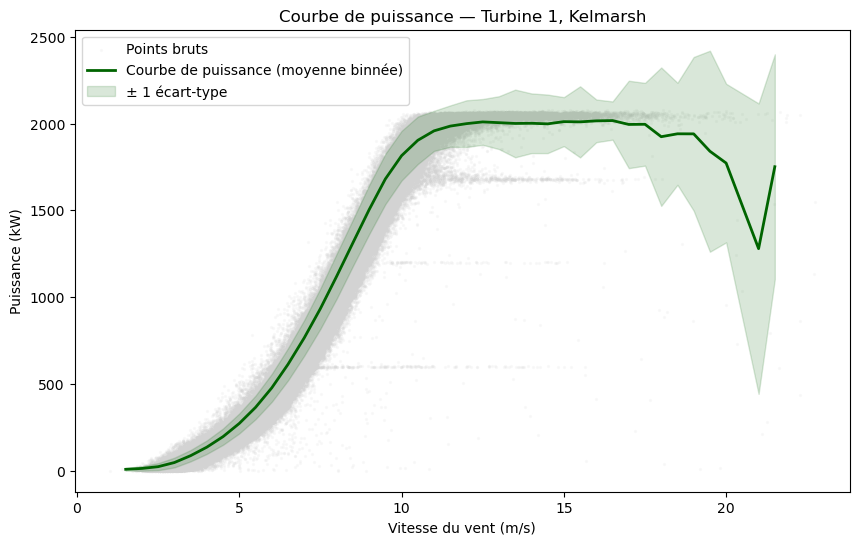

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_clean["Wind speed (m/s)"], df_clean["Power (kW)"],
            s=2, alpha=0.1, color="lightgray", label="Points bruts")
plt.plot(power_curve["wind_bin"], power_curve["mean"],
          color="darkgreen", linewidth=2, label="Courbe de puissance (moyenne binnée)")
plt.fill_between(power_curve["wind_bin"],
                  power_curve["mean"] - power_curve["std"],
                  power_curve["mean"] + power_curve["std"],
                  color="darkgreen", alpha=0.15, label="± 1 écart-type")
plt.xlabel("Vitesse du vent (m/s)")
plt.ylabel("Puissance (kW)")
plt.title("Courbe de puissance — Turbine 1, Kelmarsh")
plt.legend()
plt.show()

**Lecture du résultat** : la forme obtenue est cohérente avec le comportement attendu d'une
éolienne — démarrage progressif à partir d'environ 3 m/s, montée en puissance jusqu'à un
plateau proche de 2 000 kW (cohérent avec la puissance nominale d'une turbine Senvion MM92),
et une variabilité croissante aux vents extrêmes, où le volume de données disponibles est
naturellement plus faible.

## 5. Détection d'anomalies multivariée (Isolation Forest)

La courbe de puissance ne capture qu'une seule dimension du comportement de la turbine (vent
→ puissance). Une anomalie mécanique peut se manifester de façon plus subtile, à travers une
combinaison de plusieurs variables (température, vitesse de rotation, angle de pale) sans que
la puissance seule ne s'écarte significativement de l'attendu.

Isolation Forest est un algorithme non supervisé adapté à ce contexte : il ne nécessite pas de
labels d'anomalies (inexistants ici), gère naturellement plusieurs variables simultanément, et
ne suppose aucune distribution particulière des données — un atout important, les données SCADA
n'étant pas gaussiennes (comportement très différent selon les régimes de vent).

### Sélection des variables

Le choix des variables couvre différents sous-systèmes de la turbine, afin de limiter la
redondance et de capturer des types d'anomalies variés :

In [11]:
FEATURES = [
    "Wind speed (m/s)",                          # contexte : nécessaire pour interpréter la puissance
    "Power (kW)",                                # performance de production
    "Rotor speed (RPM)",                         # comportement mécanique
    "Gear oil temperature (°C)",                 # santé du multiplicateur
    "Generator bearing front temperature (°C)",  # santé du générateur
    "Nacelle temperature (°C)",                  # environnement global de la nacelle
    "Blade angle (pitch position) A (°)",        # comportement de régulation
]

df_if = df_clean.dropna(subset=FEATURES).copy()
X = df_if[FEATURES]

print(f"Lignes utilisées pour la détection : {len(df_if):,} / {len(df_clean):,}")

Lignes utilisées pour la détection : 216,297 / 229,457


### Standardisation et entraînement

La standardisation n'est pas strictement requise pour Isolation Forest (contrairement à des
méthodes basées sur la distance comme KNN ou SVM), mais elle limite l'influence disproportionnée
de variables à échelles très différentes — une température exprimée en dizaines de degrés face
à une puissance en milliers de kW, par exemple.

Le paramètre `contamination` fixe la proportion attendue d'anomalies dans les données. Une
valeur de 2% constitue un point de départ raisonnable dans un contexte industriel, où les
véritables dérives ou pannes restent statistiquement rares.

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42,
    n_jobs=-1,
)

df_if["anomaly_score"] = iso_forest.fit_predict(X_scaled)          # -1 = anomalie, 1 = normal
df_if["anomaly_score_raw"] = iso_forest.decision_function(X_scaled)  # score continu (plus bas = plus anormal)

n_anomalies = (df_if["anomaly_score"] == -1).sum()
print(f"Anomalies détectées : {n_anomalies:,} ({n_anomalies / len(df_if) * 100:.2f}%)")

Anomalies détectées : 4,326 (2.00%)


## 6. Visualisation des résultats

Deux vues complémentaires permettent d'interpréter les anomalies détectées :

- **Sur la courbe de puissance** : situe les anomalies par rapport au comportement attendu
  pour chaque régime de vent.
- **Dans le temps** : permet de distinguer des anomalies isolées (probablement du bruit de
  mesure ou des transitoires normaux) de véritables clusters temporels, plus évocateurs d'une
  dégradation progressive ou d'un événement mécanique réel.

Les graphiques sont construits avec Plotly (mode WebGL via `Scattergl`, nécessaire pour rester
fluide avec un volume de points de cet ordre) et exportés en HTML pour une ouverture fiable
dans un navigateur, indépendamment de la configuration d'affichage inline de l'environnement de
développement utilisé.

In [13]:
normal = df_if[df_if["anomaly_score"] == 1]
anomalies = df_if[df_if["anomaly_score"] == -1]

fig_power_curve = go.Figure()

fig_power_curve.add_trace(go.Scattergl(
    x=normal["Wind speed (m/s)"], y=normal["Power (kW)"],
    mode="markers", name="Normal",
    marker=dict(size=3, color="steelblue", opacity=0.15),
    hoverinfo="skip",  # évite d'alourdir le survol sur la masse de points normaux
))
fig_power_curve.add_trace(go.Scattergl(
    x=anomalies["Wind speed (m/s)"], y=anomalies["Power (kW)"],
    mode="markers", name="Anomalie détectée",
    marker=dict(size=5, color="red"),
    customdata=anomalies[["Date and time"]],
    hovertemplate="Vent : %{x:.1f} m/s<br>Puissance : %{y:.0f} kW<br>%{customdata[0]}<extra></extra>",
))

fig_power_curve.update_layout(
    title="Anomalies détectées (Isolation Forest) sur la courbe de puissance",
    xaxis_title="Vitesse du vent (m/s)",
    yaxis_title="Puissance (kW)",
    template="plotly_white",
    height=550,
)

fig_power_curve.write_html("power_curve_anomalies.html")

In [14]:
fig_anomaly_timeline = go.Figure()

fig_anomaly_timeline.add_trace(go.Scattergl(
    x=normal["Date and time"], y=normal["anomaly_score_raw"],
    mode="markers", name="Normal",
    marker=dict(size=3, color="steelblue", opacity=0.3),
    hoverinfo="skip",
))
fig_anomaly_timeline.add_trace(go.Scattergl(
    x=anomalies["Date and time"], y=anomalies["anomaly_score_raw"],
    mode="markers", name="Anomalie détectée",
    marker=dict(size=4, color="red"),
    hovertemplate="%{x}<br>Score : %{y:.3f}<extra></extra>",
))
fig_anomaly_timeline.add_hline(y=0, line_dash="dash", line_color="gray")

fig_anomaly_timeline.update_layout(
    title="Score d'anomalie dans le temps",
    xaxis_title="Date",
    yaxis_title="Score d'anomalie (plus bas = plus anormal)",
    template="plotly_white",
    height=450,
    xaxis=dict(rangeslider=dict(visible=True)),  # navigation temporelle par glissement
)

fig_anomaly_timeline.write_html("anomaly_score_time.html")

In [16]:
webbrowser.open("power_curve_anomalies.html")
webbrowser.open("anomaly_score_time.html")

True

## 7. Synthèse

Ce pipeline établit une référence de performance (la courbe de puissance) puis identifie des
écarts multivariés par rapport au comportement normal de la turbine, sans nécessiter de données
étiquetées — une contrainte réaliste dans un contexte de maintenance industrielle où les
véritables événements de panne sont rarement documentés de façon exhaustive.

**Limite à noter** : Isolation Forest évalue chaque observation indépendamment, sans notion de
continuité temporelle. Une dérive progressive et lente (par exemple une température qui
augmente très graduellement sur plusieurs jours) peut ne jamais franchir individuellement le
seuil d'anomalie, même si la tendance est significative sur la durée. La vue temporelle des
scores permet d'atténuer partiellement cette limite en révélant les tendances visuellement,
mais une approche complémentaire (analyse de séries temporelles, détection de rupture) serait
nécessaire pour la traiter plus rigoureusement.

**Pistes d'approfondissement** :
- Requêtage SQL (via DuckDB par exemple) pour des agrégations et comparaisons entre turbines
  du même parc.
- Analyse de l'importance relative des variables dans les anomalies détectées (comparaison de
  distributions entre points normaux et anormaux).
- Détection de rupture ou de tendance sur les séries temporelles, en complément de l'approche
  ponctuelle actuelle.
